# Parameter Estimation with Maximum Likelihood

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

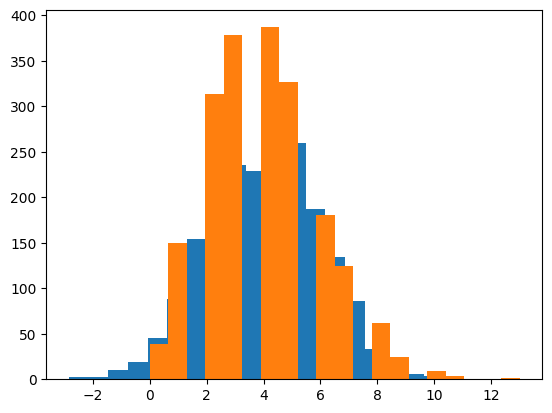

Mean:  4.03726268815454
Variance & StdDev:  3.9513516698864137 1.9878007118135395


In [144]:
N=2000

gData = np.random.normal(loc=4,scale=2,size=N)
pData = np.random.poisson(lam=4,size=N)

plt.hist(gData,bins=20)
plt.hist(pData,bins=20)
plt.show()

cData = gData
# Calculate mean
mean = sum(cData)/N

# Calculate variance & standard deviation
vData = cData - mean
vData2 = vData*vData
variance = sum(vData2)/(N-1)

print("Mean: ",mean)
print("Variance & StdDev: ",variance, np.sqrt(variance))

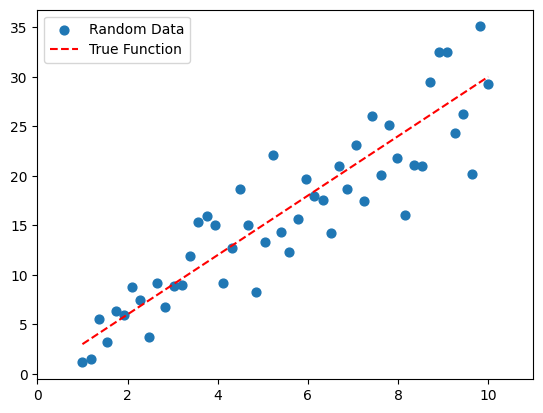

In [99]:
def makeLinearData(N,xmin,xmax,slope):
    X = np.linspace(xmin,xmax,N)
    Y = slope*X
    for i in range(0,N):
        Y[i] += np.random.randn()*np.sqrt(abs(Y[i]))
    return Y


# Make some data!!
# Gonna be a set of noisy data drawn from a linear function
N = 50 # number of points per class
xmin = 1 
xmax = 10
slope = 3
X = np.linspace(xmin,xmax,N)
xline = [xmin,xmax]
yline = [offset+xmin*slope,offset+slope*xmax]
y_true = slope*X

# We will explore the role that the size of the noise plays
# Why did I choose this value to begin with?
noise = np.sqrt(np.mean(y_true))

y_data = makeData(N,xmin,xmax,slope)

plt.scatter(X, y_data, s=40, label = "Random Data")
plt.xlim(xmin-1,xmax+1)
plt.plot(xline,yline,linestyle="--",color="r", label="True Function")
plt.legend()
plt.show()

In [100]:
def lhood_func_gaussian(ymodel,ydata):
    return -0.5*np.pow((ydata - ymodel),2)/ymodel

def lhood_func_poisson(ymodel,ydata):
    return ydata*np.log(ymodel) - ymodel

def loglikelihood(pSlope,xvals,yvals, doGaus = True):
    loglhood = 0
    y_model = pSlope*xvals

    for i in range(0,len(xvals)):
        if doGaus:
            loglhood += lhood_func_gaussian(y_model[i],yvals[i])
        else:
            loglhood += lhood_func_poisson(y_model[i],yvals[i])
            
    return loglhood

def getStdDevVals(llhood,slope,maxLH):
    slopeP1 = 0
    slopeP2 = 0
    foundFirst1 = False
    foundFirst2 = False
    for i in range(0,len(llhood)):
        if (llhood[i]> (maxLH-0.5)) and (foundFirst1 == False):
            slopeP1 = slope[i]
            foundFirst1 = True

        if (llhood[i]< (maxLH-0.5)) and (foundFirst1 == True) and (foundFirst2==False):
            slopeP2 = slope[i]
            foundFirst2 = True
    return slopeP1, slopeP2

def findMaxima(XX, data, llhoodG, llhoodP,slopeVals):
    maxG = -1E7
    maxP = -1E7
    sbestG = 0
    sbestP = 0
    for x, s in enumerate(slopeVals):
        llhoodG[x] = loglikelihood(s,XX,data,doGaus=True)
        if llhoodG[x] > maxG:
            maxG = llhoodG[x]
            sbestG = s
            
        llhoodP[x] = loglikelihood(s,XX,data,doGaus=False)
        if llhoodP[x] > maxP:
            maxP = llhoodP[x]
            sbestP = s
    return sbestG, maxG, sbestP, maxP

In [107]:
steps = 500
llhoodG = np.zeros(steps)
llhoodP = np.zeros(steps)
smin = 2.7
smax = 3.3

slopeVals = np.arange(smin,smax,(smax-smin)/steps)

sbestG, maxG, sbestP, maxP = findMaxima(X, y_data, llhoodG, llhoodP, slopeVals)

llhoodG += maxP-maxG

std1G, std2G = getStdDevVals(llhoodG,slopeVals,maxP)
std1P, std2P = getStdDevVals(llhoodP,slopeVals,maxP)

print("Gaussian Maximum: {:.3f} {:.3f} {:.3f}".format(sbestG,std1G-sbestG,std2G-sbestG))
print(" Poisson Maximum: {:.3f} {:.3f} {:.3f}".format(sbestP,std1P-sbestP,std2P-sbestP))


Gaussian Maximum: 3.004 -0.102 0.107
 Poisson Maximum: 2.935 -0.102 0.104


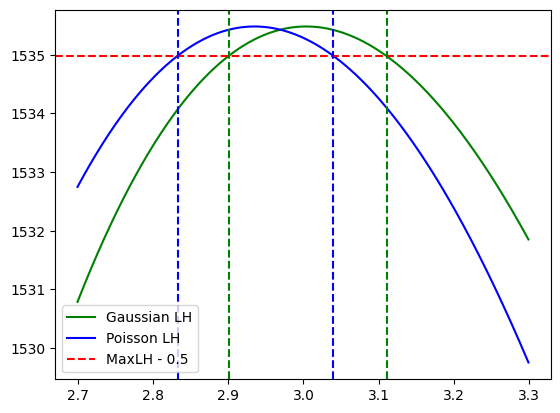

In [108]:
plt.plot(slopeVals,llhoodG,c='g',label="Gaussian LH")
plt.plot(slopeVals,llhoodP,c='b',label="Poisson LH")
plt.axhline(y=maxP-0.5,c='r',linestyle="--",label = "MaxLH - 0.5")
plt.axvline(x=std2P,c='b',linestyle="--")
plt.axvline(x=std1P,c='b',linestyle="--")
plt.axvline(x=std2G,c='g',linestyle="--")
plt.axvline(x=std1G,c='g',linestyle="--")
plt.legend()
plt.show()

In [114]:
smin = 2
smax = 4
slopeVals = np.arange(smin,smax,(smax-smin)/steps)

nTrials = 1000
slopeFitG = np.zeros(nTrials)
slopeFitP = np.zeros(nTrials)

for i in range(0,nTrials):
    y_tmp = makeData(N,xmin,xmax,slope)
    sbestG, maxG, sbestP, maxP = findMaxima(X, y_tmp, llhoodG, llhoodP,slopeVals)
    slopeFitG[i] = sbestG
    slopeFitP[i] = sbestP

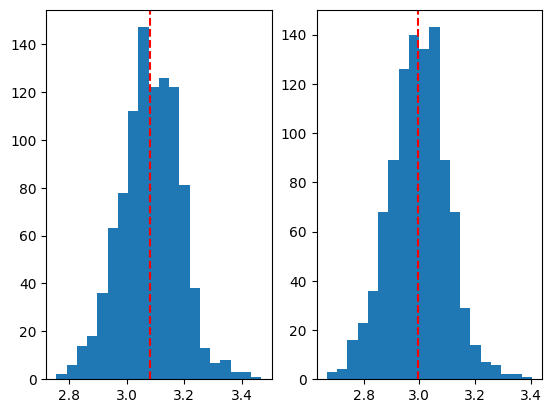

In [115]:
fig, axs = plt.subplots(nrows=1,ncols=2)
axs[0].hist(slopeFitG,bins=20)
axs[0].axvline(x=np.mean(slopeFitG),c='r',linestyle="--")
axs[1].hist(slopeFitP,bins=20)
axs[1].axvline(x=np.mean(slopeFitP),c='r',linestyle="--")
plt.show()